# 1. IMPORT LIBRARIES

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import warnings
warnings.filterwarnings('ignore')

plt.style.use("ggplot")


# 2. LOAD DATA (UCI Online Retail)

In [36]:
df = pd.read_excel("/content/Online Retail.xlsx")


# 3. PRE-DATA CLEANING

In [37]:
print("\nInitial Shape:", df.shape)


Initial Shape: (541909, 8)


In [38]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [39]:
# Remove missing CustomerID
df = df.dropna(subset=["InvoiceNo", "StockCode", "Description", "InvoiceDate"])

In [40]:
# Remove negative or zero quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [41]:
# Convert to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Shape After Cleaning:", df.shape)


Shape After Cleaning: (524878, 8)


# 4. FEATURE CREATION

In [42]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# 5. EDA + VISUALISATIONS BEFORE SPLITTING

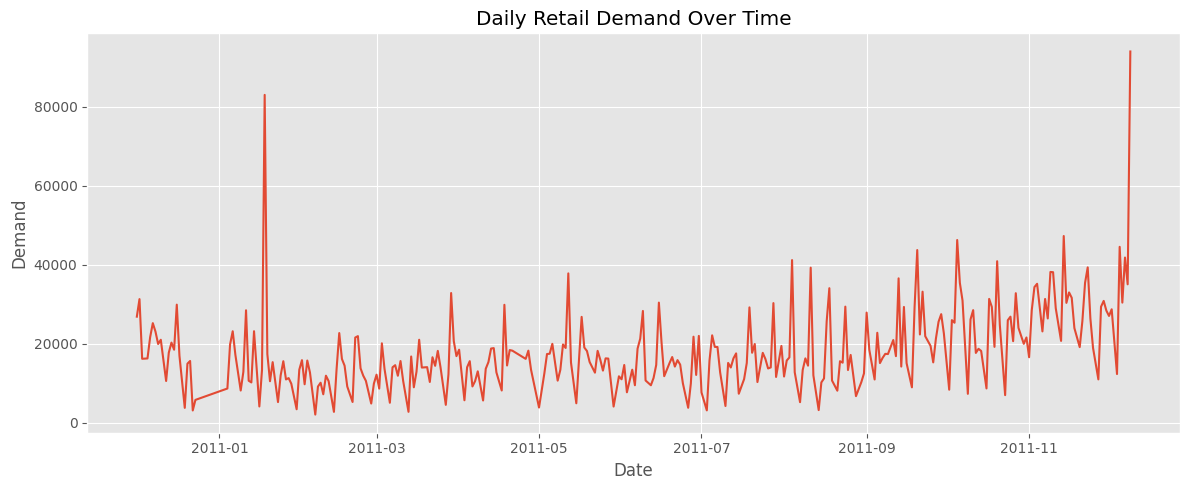

In [43]:
# 1. Daily demand trend
daily = df.groupby(df["InvoiceDate"].dt.date)["Quantity"].sum().reset_index()
daily.columns = ["Date", "Demand"]

plt.figure(figsize=(12,5))
plt.plot(daily["Date"], daily["Demand"])
plt.title("Daily Retail Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()

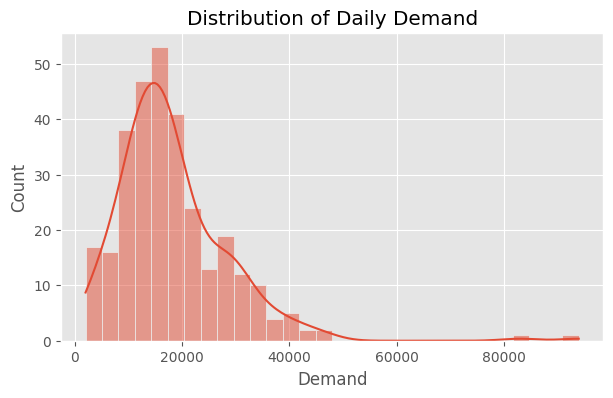

In [44]:
# 2. Distribution of demand
plt.figure(figsize=(7,4))
sns.histplot(daily["Demand"], kde=True)
plt.title("Distribution of Daily Demand")
plt.show()

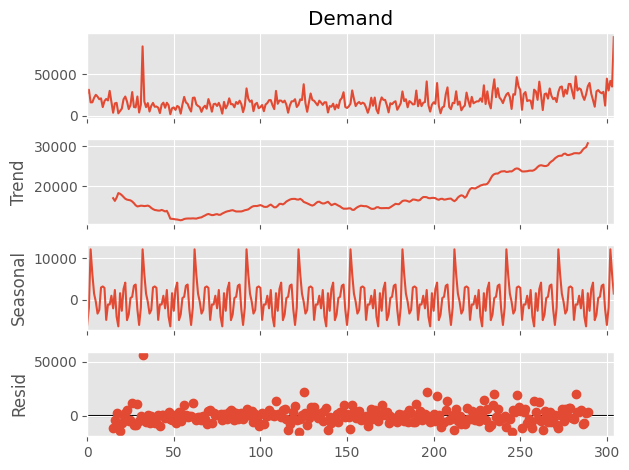

In [45]:
# 3. Seasonal decomposition (trend, seasonal, residual)
decomp = seasonal_decompose(daily["Demand"], period=30, model="additive")
decomp.plot()
plt.tight_layout()
plt.show()


# 6. ANOMALY DETECTION

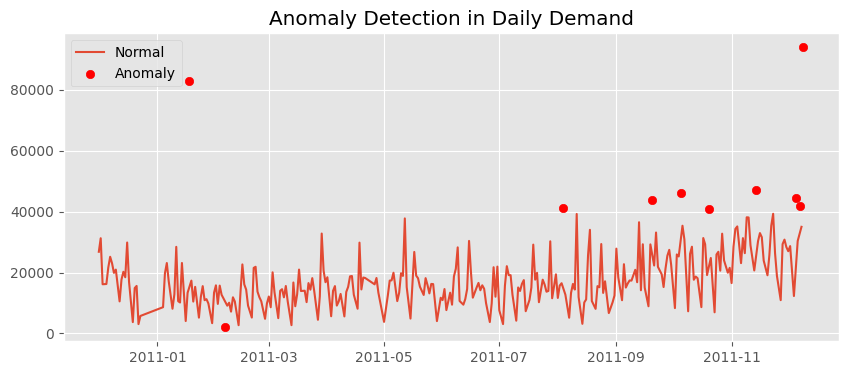

In [46]:
iso = IsolationForest(contamination=0.03, random_state=42)
daily["anomaly"] = iso.fit_predict(daily[["Demand"]])
daily_clean = daily[daily["anomaly"] == 1]  # keep only normal points

plt.figure(figsize=(10,4))
plt.plot(daily_clean["Date"], daily_clean["Demand"], label="Normal")
plt.scatter(
    daily[daily["anomaly"] == -1]["Date"],
    daily[daily["anomaly"] == -1]["Demand"],
    color="red", label="Anomaly"
)
plt.title("Anomaly Detection in Daily Demand")
plt.legend()
plt.show()

# 7. TRAIN-TEST SPLIT

In [47]:
train = daily_clean[:-30]
test = daily_clean[-30:]

# 8. ARIMA MODEL

In [48]:
arima_model = ARIMA(train["Demand"], order=(5,1,2))
arima_fit = arima_model.fit()

In [49]:
arima_pred = arima_fit.forecast(len(test))

# 9. ML MODELS – RF / XGB

In [50]:
daily_clean["Day"] = pd.to_datetime(daily_clean["Date"]).dt.dayofyear

X = daily_clean[["Day"]]
y = daily_clean["Demand"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, shuffle=False
)

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

xgb = XGBRegressor()
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

# 10. LSTM MODEL

In [51]:
def create_sequences(data, window=7):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window])
    return np.array(X), np.array(y)

series = daily_clean["Demand"].values
X_lstm, y_lstm = create_sequences(series)

X_lstm = X_lstm.reshape((X_lstm.shape[0], X_lstm.shape[1], 1))

split = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(7,1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

model.fit(X_train_lstm, y_train_lstm, epochs=20, verbose=1)

lstm_pred = model.predict(X_test_lstm).flatten()


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 157467328.0000
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 128377072.0000 
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 59439832.0000 
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 43540640.0000 
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 44347888.0000 
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 42658044.0000 
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 51144468.0000 
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 42962032.0000 
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 43652112.0000 
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 43550708.0000 
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 42936860.0000 
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 42604908.0000 
Epoch 13/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 48310888.0000 
Epoch 14/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45719276.0000 


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step


# 11. EVALUATION

In [52]:
def evaluate(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    print(f"{name} — MAE: {mae:.2f}, RMSE: {rmse:.2f}")

print("\nMODEL PERFORMANCE:")
evaluate(test["Demand"], arima_pred, "ARIMA")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, xgb_pred, "XGBoost")
evaluate(y_test_lstm, lstm_pred, "LSTM")


MODEL PERFORMANCE:
ARIMA — MAE: 7662.04, RMSE: 8789.20
Random Forest — MAE: 6831.48, RMSE: 8384.54
XGBoost — MAE: 7756.29, RMSE: 9143.92
LSTM — MAE: 6509.34, RMSE: 7838.08


# 12. VISUALISATION OF MODEL PERFORMANCE

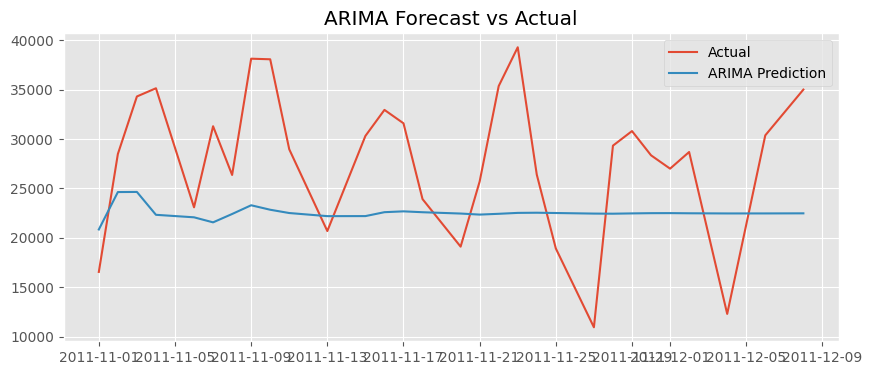

In [53]:
# 1. ARIMA prediction vs actual
plt.figure(figsize=(10,4))
plt.plot(test["Date"], test["Demand"], label="Actual")
plt.plot(test["Date"], arima_pred, label="ARIMA Prediction")
plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()


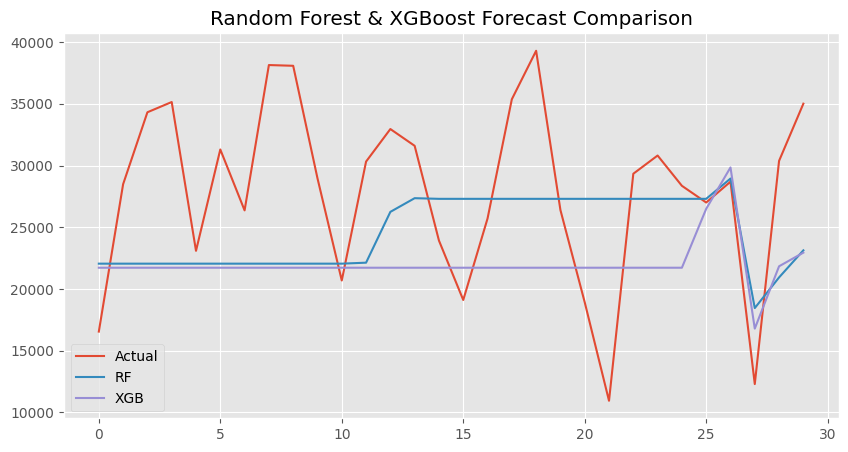

In [54]:
# 2. RF vs XGB vs Actual
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(rf_pred, label="RF")
plt.plot(xgb_pred, label="XGB")
plt.title("Random Forest & XGBoost Forecast Comparison")
plt.legend()
plt.show()


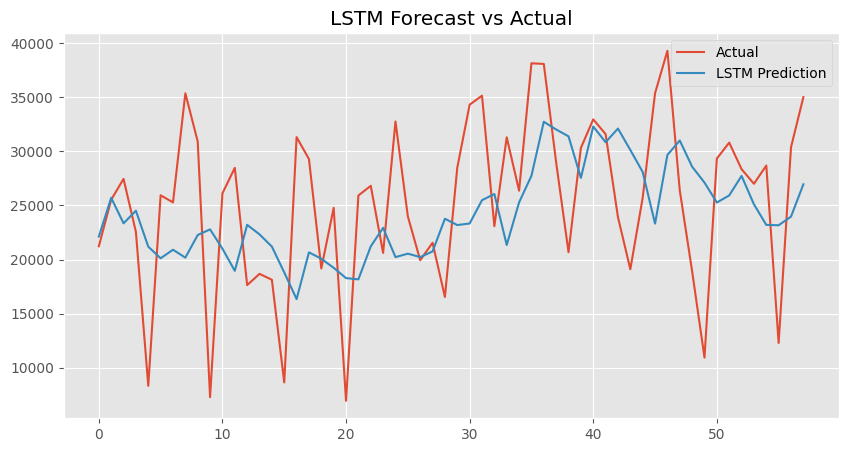

In [55]:
# 3. LSTM predictions
plt.figure(figsize=(10,5))
plt.plot(y_test_lstm, label="Actual")
plt.plot(lstm_pred, label="LSTM Prediction")
plt.title("LSTM Forecast vs Actual")
plt.legend()
plt.show()